In [1]:
from pathlib import Path
from datetime import datetime, timedelta, date
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from unityvr.preproc import logproc as lp
from unityvr.analysis import posAnalysis, align2img
from gulp2p.preproc import utils, behavior
from gulp2p.preproc.tiff import Tiff
from gulp2p.config import BHV_DATA_RAW_DIR

### Logging config

In [2]:
log_level = logging.INFO    # log levels: DEBUG, INFO, WARNING, ERROR, CRITICAL
log_format = "{asctime} - {levelname} - {name} - [{filename} {funcName}() {lineno}] - {message}"
logging.basicConfig(format=log_format, level=log_level, style="{") 

logging.getLogger("gulp2p").setLevel(logging.DEBUG)
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

### User Settings

In [3]:
tiff_folder = Path(r"Z:\2PImaging\Kerstin\MIMS")
bhv_folder = BHV_DATA_RAW_DIR
PURGE_TIFF_METADATA = True

## Compare tiff and bhv creation times

In [4]:
# do this for all bhv and tiffs in kerstins mimms folder
# Ignore time differences greater than 1 maybe 2 minutes (?)
# Need a way to synce up tiff and bhv files

In [5]:
def find_bhv_path_from_tiff(tiff_timestamp, bhv_folder=None):
    if bhv_folder is None:
        bhv_folder = Path(r"Z:\Live Fly Imaging data\unity\raw data")
    min_diff = None
    min_file = None
    for path in bhv_folder.rglob("*"):
        if not path.is_file():
            continue
        try:
            file_timestamp = utils.get_timestamp_from_string(path.name)
        except:
            continue

        time_diff = file_timestamp - tiff_timestamp
        if min_diff is None:
            min_diff = time_diff
            min_file = path
        if abs(time_diff) < abs(min_diff):
            min_diff = time_diff
            min_file = path
    return min_file, min_diff



In [6]:
tiff_paths = []
for path in tiff_folder.rglob("*"):
    if path.suffix != ".tif":
        continue
    if path.name in [p.name for p in tiff_paths]:
        continue
    tiff_paths.append(path)

df_dicts = []
for tiff_path in tiff_paths:
    tiff = Tiff(tiff_path)
    if PURGE_TIFF_METADATA:
        try:
            if hasattr(tiff, 'metadata'):
                del tiff.metadata
                logger.debug(f"Deleted metadata cache of {tiff_path.name}")
        except AttributeError:
            logger.debug(f"Couldn't delete metadata cache of {tiff_path.name}")
            pass
    tiff_date = tiff.metadata['date']
    tiff_timestamp = tiff_date.timestamp()
    bhv_path, min_diff = find_bhv_path_from_tiff(tiff_timestamp)
    bhv_date = datetime.fromtimestamp(utils.get_timestamp_from_string(bhv_path.name))
    df_dicts.append({"tiff_date": tiff_date,
                     "bhv_date": bhv_date})
dates_df = pd.DataFrame(df_dicts)

dates_df['diff'] = dates_df['tiff_date'] - dates_df['bhv_date']

2024-07-23 13:21:43,422 - DEBUG - gulp2p.preproc.tiff - [tiff.py get_scanimage_metadata() 139] - tiff modification time is earlier than creation time
2024-07-23 13:21:43,438 - DEBUG - __main__ - [2019953992.py <module>() 16] - Deleted metadata cache of Fly1_8days_iGluSnFRxSS2232_00001.tif
2024-07-23 13:21:49,139 - DEBUG - gulp2p.preproc.tiff - [tiff.py get_scanimage_metadata() 139] - tiff modification time is earlier than creation time
2024-07-23 13:21:49,155 - DEBUG - __main__ - [2019953992.py <module>() 16] - Deleted metadata cache of Fly1_8days_iGluSnFRxSS2232_00002.tif
2024-07-23 13:21:53,743 - DEBUG - gulp2p.preproc.tiff - [tiff.py get_scanimage_metadata() 139] - tiff modification time is earlier than creation time
2024-07-23 13:21:53,761 - DEBUG - __main__ - [2019953992.py <module>() 16] - Deleted metadata cache of Fly1_8days_iGluSnFRxSS2232_00003.tif
2024-07-23 13:21:58,331 - DEBUG - gulp2p.preproc.tiff - [tiff.py get_scanimage_metadata() 139] - tiff modification time is earlier

In [7]:
dates_df.head()

,tiff_date,bhv_date,diff
0,2023-11-09 14:56:55.361745,2023-11-09 15:07:44,-1 days +23:49:11.361745
1,2023-11-09 15:11:52.887970,2023-11-09 15:10:08,0 days 00:01:44.887970
2,2023-11-09 15:13:49.404712,2023-11-09 15:10:08,0 days 00:03:41.404712
3,2023-11-09 15:19:08.889896,2023-11-09 15:21:44,-1 days +23:57:24.889896
4,2023-11-09 15:21:45.755689,2023-11-09 15:21:44,0 days 00:00:01.755689


In [8]:
# tiff is created about 33 seconds after bhv file
dates_df.describe()

,tiff_date,bhv_date,diff
count,242,242,242
mean,2024-02-04 01:24:43.400723712,2024-02-04 01:25:51.074380032,-1 days +23:58:52.326343484
min,2023-11-09 14:56:55.361745,2023-11-09 15:07:44,-1 days +18:40:50.162206
25%,2023-12-06 11:10:11.850355712,2023-12-06 11:09:54.249999872,0 days 00:00:05.988007750
50%,2024-01-17 10:55:43.035245568,2024-01-17 10:55:40.500000,0 days 00:00:24.647003500
75%,2024-02-15 11:33:12.486952448,2024-02-15 11:31:44,0 days 00:01:08.591324500
max,2024-07-08 12:34:29.201081,2024-07-08 12:33:45,0 days 00:11:33.426860
std,NaN,NaN,0 days 00:21:15.037647823


In [9]:
dates_df_filtered = dates_df[(dates_df["diff"] < timedelta(minutes=5)) & (dates_df["diff"] > timedelta(minutes=-5))]

In [10]:
dates_df_filtered.describe()

,tiff_date,bhv_date,diff
count,232,232,232
mean,2024-02-04 06:29:38.834127104,2024-02-04 06:29:10.142241536,0 days 00:00:28.691885724
min,2023-11-09 15:11:52.887970,2023-11-09 15:10:08,-1 days +23:56:34.093432
25%,2023-12-06 11:21:27.545385984,2023-12-06 11:21:10,0 days 00:00:06.192766250
50%,2024-01-17 10:55:43.035245568,2024-01-17 10:55:40.500000,0 days 00:00:24.647003500
75%,2024-02-15 11:36:59.831446528,2024-02-15 11:35:31.249999872,0 days 00:01:08.403871750
max,2024-07-08 12:34:29.201081,2024-07-08 12:33:45,0 days 00:03:41.404712
std,NaN,NaN,0 days 00:00:48.822871221


In [11]:
dates_df_filtered

,tiff_date,bhv_date,diff
1,2023-11-09 15:11:52.887970,2023-11-09 15:10:08,0 days 00:01:44.887970
2,2023-11-09 15:13:49.404712,2023-11-09 15:10:08,0 days 00:03:41.404712
3,2023-11-09 15:19:08.889896,2023-11-09 15:21:44,-1 days +23:57:24.889896
4,2023-11-09 15:21:45.755689,2023-11-09 15:21:44,0 days 00:00:01.755689
6,2023-11-21 11:45:36.960844,2023-11-21 11:48:54,-1 days +23:56:42.960844
...,...,...,...
237,2024-07-08 12:05:58.045388,2024-07-08 12:05:13,0 days 00:00:45.045388
238,2024-07-08 12:13:37.827949,2024-07-08 12:12:53,0 days 00:00:44.827949
239,2024-07-08 12:20:35.453217,2024-07-08 12:19:51,0 days 00:00:44.453217
240,2024-07-08 12:27:31.105077,2024-07-08 12:26:46,0 days 00:00:45.105077


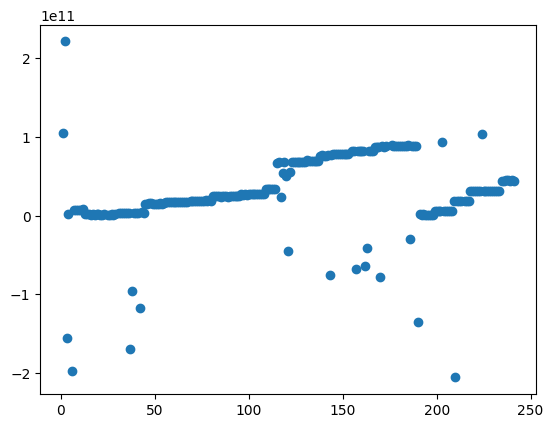

In [12]:
ax = plt.subplot()
ax.scatter(dates_df_filtered.index, dates_df_filtered['diff'])

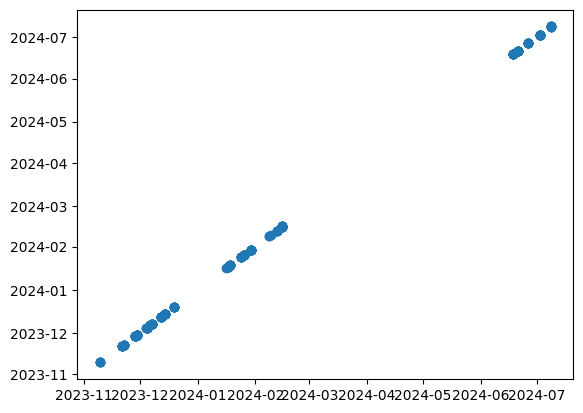

In [13]:
plt.scatter(dates_df_filtered['tiff_date'], dates_df_filtered['bhv_date'])

## Plot recording intervals over an experiment

In [14]:
def convert_interval_units(time_interval):
    # Convert from timestamp to minutes since midnight
    date_day = date.fromtimestamp(time_interval[0])
    new_interval = []
    for timepoint in time_interval:
        midnight_timestamp = datetime.combine(date_day, datetime.min.time()).timestamp()
        seconds_since_midnight = timepoint - midnight_timestamp
        hour_since_midnight = seconds_since_midnight / 60 / 60
        new_interval.append(hour_since_midnight)
    return new_interval

In [15]:
def get_tiff_interval(tiff):
    tiff_start_time = tiff.metadata['date'].timestamp()
    tiff_length = tiff.length
    tiff_interval = (tiff_start_time, tiff_start_time + tiff_length)
    return tiff_interval

def get_bhv_interval(bhv_path):
    bhv_start_time = utils.get_timestamp_from_string(bhv_path.name)
    bhv_length = utils.get_bhv_length(bhv_path)
    if bhv_length is None:
        bhv_length = 0
    bhv_interval = (bhv_start_time, bhv_start_time + bhv_length)
    return bhv_interval

In [16]:
def plot_interval(interval, ax, y, color="C0"):
    ax.plot(interval, [y,y], c=color, marker='o', ms=2)

def plot_intervals(intervals, ax, y, color="C0", dodge=0.1):
    for index, interval in enumerate(intervals):
        if index % 2 == 0:
            jitter = 1 * dodge
        else:
            jitter = -1 * dodge
        plot_interval(interval, ax, y=y+jitter, color=color)

In [17]:
df_dicts = []
for path in tiff_folder.rglob("*"):
    if path.suffix != ".tif":
        continue
    if path.name in [row['path'].name for row in df_dicts]:
        continue
    tiff = Tiff(path)
    df_dicts.append({"path": path,
                     "tiff": tiff,
                     "datetime": tiff.metadata['date']})

tiff_df = pd.DataFrame(df_dicts)

In [18]:
tiff_df['date'] = tiff_df['datetime'].apply(lambda x:x.date())
tiff_df['interval'] = tiff_df['tiff'].apply(get_tiff_interval)
tiff_df['interval_sub_midnight'] = tiff_df['interval'].apply(convert_interval_units)

In [19]:
tiff_df.head()

,path,tiff,datetime,date,interval,interval_sub_midnight
0,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2023-11-09 14:56:55.361745,2023-11-09,"(1699570615.361745, 1699570815.417345)","[14.948711595866415, 15.004282595846387]"
1,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2023-11-09 15:11:52.887970,2023-11-09,"(1699571512.88797, 1699571564.41357)","[15.198024436102973, 15.21233710275756]"
2,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2023-11-09 15:13:49.404712,2023-11-09,"(1699571629.404712, 1699571680.9306118)","[15.230390197767152, 15.244702947735787]"
3,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2023-11-09 15:19:08.889896,2023-11-09,"(1699571948.889896, 1699572000.414896)","[15.319136082198886, 15.333448582225376]"
4,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2023-11-09 15:21:45.755689,2023-11-09,"(1699572105.755689, 1699572425.2199888)","[15.36270991358492, 15.45144999689526]"


In [20]:
df_dicts = []
for path in bhv_folder.rglob("*"):
    if path.suffix != ".json":
        continue
    if path.stem == "SessionParameters":
        continue
    if path.name in [row['path'].name for row in df_dicts]:
        continue
    bhv_timestamp = utils.get_timestamp_from_string(path.name)
    bhv_datetime = datetime.fromtimestamp(bhv_timestamp)
    df_dicts.append({"path": path,
                     "datetime": bhv_datetime})

bhv_df = pd.DataFrame(df_dicts)

In [21]:
bhv_df['date'] = bhv_df['datetime'].apply(lambda x:x.date())
bhv_df['interval'] = bhv_df['path'].apply(get_bhv_interval)
bhv_df['interval_sub_midnight'] = bhv_df['interval'].apply(convert_interval_units)

In [22]:
bhv_df.head()

,path,datetime,date,interval,interval_sub_midnight
0,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-13 10:49:54,2022-12-13,"(1670957394.0, 1670957993.446289)","[10.831666666666667, 10.998179524739584]"
1,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-13 11:09:47,2022-12-13,"(1670958587.0, 1670959186.4534302)","[11.163055555555555, 11.32957039727105]"
2,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-13 11:35:09,2022-12-13,"(1670960109.0, 1670960708.4599)","[11.585833333333333, 11.752349972195097]"
3,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-14 10:18:55,2022-12-14,"(1671041935.0, 1671042534.2382812)","[10.315277777777776, 10.481732855902777]"
4,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-14 10:29:39,2022-12-14,"(1671042579.0, 1671043178.4607544)","[10.494166666666667, 10.66068354288737]"


In [23]:
def shift_intervals(intervals, shift):
    shifted_intervals = []
    for interval in intervals:
        shifted = [point + shift for point in interval]
        shifted_intervals.append(shifted)
    return shifted_intervals

def get_overlapping_intervals(main_intervals, secondary_intervals):
    overlapping_intervals = []
    for main_interval in main_intervals:
        for secondary_interval in secondary_intervals:
            interval_overlap = utils.get_overlap(main_interval, secondary_interval)
            if interval_overlap is None:
                continue
            overlapping_intervals.append(interval_overlap)
    return overlapping_intervals

def deduplicate_intervals(intervals):
    sorted_intervals = sorted(intervals, key=lambda x: x[0])
    i = 0
    while (i < len(sorted_intervals)-1):
        interval = sorted_intervals[i]
        next_interval = sorted_intervals[i+1]
        start_point = interval[0]
        if next_interval[0] <= interval[1]:
            end_point = max(interval[1], next_interval[1])
            combined_interval = [start_point, end_point]
            sorted_intervals[i:i+1+1] = [combined_interval]
        else:
            i += 1
    return sorted_intervals

def get_length_of_intervals(intervals):
    length = 0
    for interval in intervals:
        length += interval[1] - interval[0]
    return length

def calculate_coverage(main_intervals, secondary_intervals, with_duplicates=False):
    overlapping_intervals = get_overlapping_intervals(main_intervals, secondary_intervals)
    if not with_duplicates:
        overlapping_intervals = deduplicate_intervals(overlapping_intervals)

    covered_length = get_length_of_intervals(overlapping_intervals)
    total_length = get_length_of_intervals(main_intervals)
    coverage = covered_length / total_length
    return coverage

In [24]:
def plot_expt_file_intervals(expt_date, tiff_df, bhv_df, ax, with_overlaps=False):

    tiff_df_subset = tiff_df[tiff_df['date'] == expt_date]
    bhv_df_subset = bhv_df[bhv_df['date'] == expt_date]

    # plot all intervals and see if they can be aligned by shifting
    tiff_intervals = list(tiff_df_subset['interval_sub_midnight'])
    bhv_intervals = list(bhv_df_subset['interval_sub_midnight'])
    plot_intervals(tiff_intervals, ax, y=1, color="C0")
    plot_intervals(bhv_intervals, ax, y=2, color="C1")
    ax.set_ylim([0.5, 2.5])
    if with_overlaps:
        overlaps = get_overlapping_intervals(tiff_intervals, bhv_intervals)
        deduplicated_overlaps = deduplicate_intervals(overlaps)
        plot_intervals(overlaps, ax, y=3, color="C2")
        plot_intervals(deduplicated_overlaps, ax, y=4, color="C3")
        ax.set_ylim([0.5, 2.5+2])
    ax.set_yticks([1, 2], ["tiff", "bhv"])
    ax.set_title(expt_date)

    min_diffs = []
    for i, tiff_row in tiff_df_subset.iterrows():
        # print(tiff_row['path'].name)
        tiff_ts = tiff_row['datetime'].timestamp()
        min_diff = None
        for j, bhv_row in bhv_df_subset.iterrows():
            bhv_ts = bhv_row['datetime'].timestamp()
            diff = bhv_ts - tiff_ts
            if min_diff is None:
                min_diff = diff
            if diff > 0:
                continue
            if abs(diff) < abs(min_diff):
                min_diff = diff
                bhv_path = bhv_row['path']
        min_diffs.append(min_diff)
    try:
        mean = np.mean(min_diffs)
        std = np.std(min_diffs)
        ax.text(x=0.5, y=0.5, s=f"mean: {mean}, std: {std}",
                ha='center', va='center', transform=ax.transAxes)
    except:
        pass

    return ax

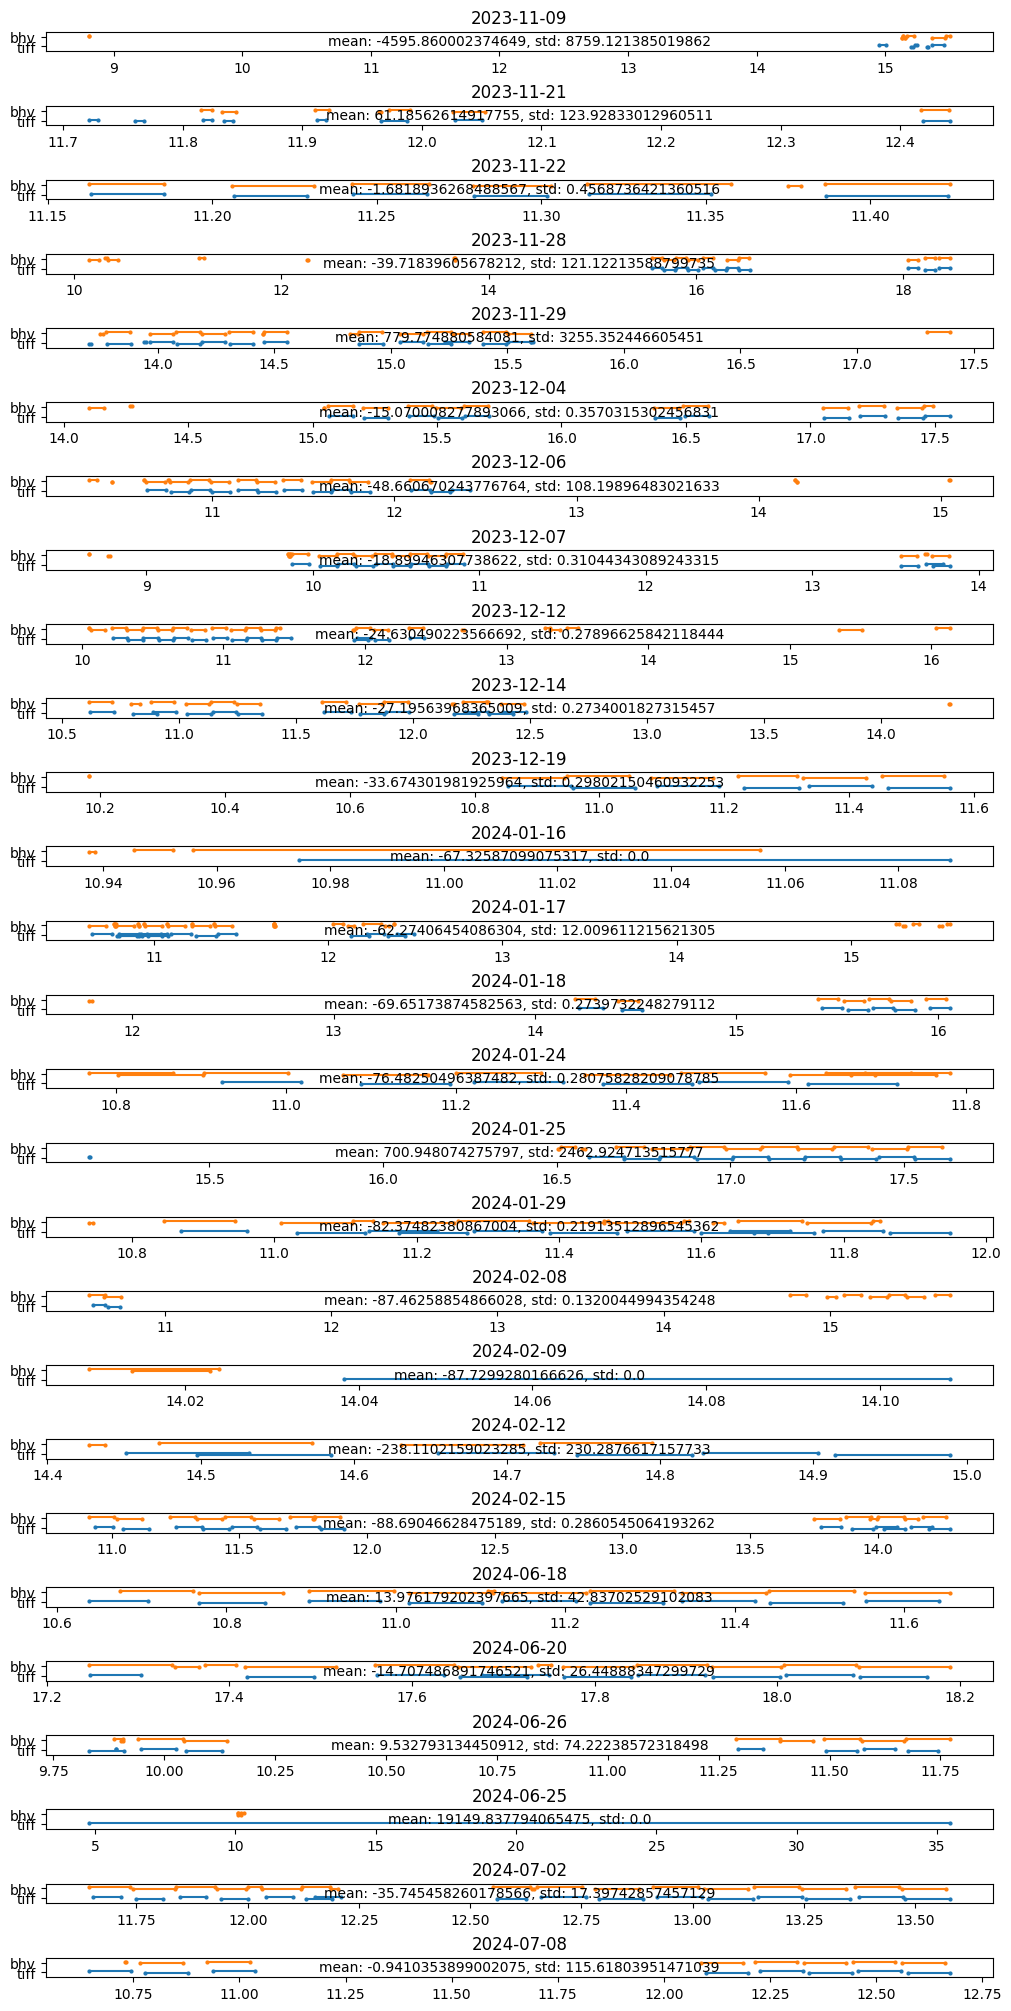

In [25]:
expt_dates = tiff_df['date'].unique()
fig, axs = plt.subplots(len(expt_dates), figsize=(10,20), layout="constrained")
for index, expt_date in enumerate(expt_dates):
    plot_expt_file_intervals(expt_date, tiff_df, bhv_df, axs[index])

In [26]:
# Is the delay for any given day the same?
# If so I can use that to align the tiff and behavioral data

### Check if the delay between tiff and bhv creation date is consistent during one recording session.

In [27]:
expt_date = date.fromisoformat("2024-07-08")
tiff_df_subset = tiff_df[tiff_df['date'] == expt_date]
bhv_df_subset = bhv_df[bhv_df['date'] == expt_date]

<Axes: title={'center': '2024-07-08'}>

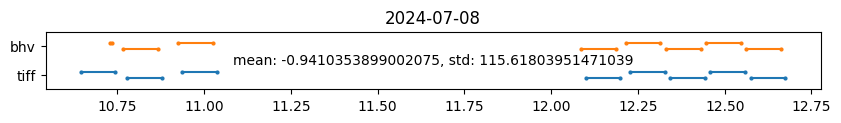

In [28]:
fig, ax = plt.subplots(figsize=(10,0.75))
plot_expt_file_intervals(expt_date, tiff_df, bhv_df, ax)

In [29]:
tiff_df_subset

,path,tiff,datetime,date,interval,interval_sub_midnight
234,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 10:38:40.045530,2024-07-08,"(1720460320.04553, 1720460679.6720042)","[10.644457091689109, 10.744353334506352]"
235,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 10:46:42.337772,2024-07-08,"(1720460802.337772, 1720461162.0844822)","[10.778427158859042, 10.878356800609165]"
236,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 10:56:12.512269,2024-07-08,"(1720461372.512269, 1720461732.2589793)","[10.93680896361669, 11.036738605366814]"
237,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 12:05:58.045388,2024-07-08,"(1720465558.045388, 1720465917.7920983)","[12.09945705221759, 12.199386693967712]"
238,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 12:13:37.827949,2024-07-08,"(1720466017.827949, 1720466377.5746593)","[12.227174430290859, 12.327104072040981]"
239,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 12:20:35.453217,2024-07-08,"(1720466435.453217, 1720466795.1999273)","[12.343181449174882, 12.443111090925006]"
240,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 12:27:31.105077,2024-07-08,"(1720466851.105077, 1720467210.8517873)","[12.45864029917452, 12.558569940924645]"
241,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 12:34:29.201081,2024-07-08,"(1720467269.201081, 1720467628.9477913)","[12.574778078065979, 12.674707719816102]"


In [30]:
bhv_df_subset

,path,datetime,date,interval,interval_sub_midnight
820,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-07-08 10:43:45,2024-07-08,"(1720460625.0, 1720460639.0479527)","[10.729166666666666, 10.73306887573666]"
821,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-07-08 10:45:58,2024-07-08,"(1720460758.0, 1720461117.274292)","[10.766111111111112, 10.865909525553384]"
822,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-07-08 10:55:28,2024-07-08,"(1720461328.0, 1720461687.2661438)","[10.924444444444445, 11.024240595499673]"
823,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-07-08 12:05:13,2024-07-08,"(1720465513.0, 1720465872.2580566)","[12.086944444444445, 12.186738349066841]"
824,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-07-08 12:12:53,2024-07-08,"(1720465973.0, 1720466332.266327)","[12.214722222222223, 12.314518424140083]"
825,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-07-08 12:19:51,2024-07-08,"(1720466391.0, 1720466750.276062)","[12.330833333333334, 12.4306322394477]"
826,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-07-08 12:26:46,2024-07-08,"(1720466806.0, 1720467164.9164429)","[12.446111111111112, 12.545810123019749]"
827,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-07-08 12:33:45,2024-07-08,"(1720467225.0, 1720467584.258484)","[12.5625, 12.662294023301866]"


In [31]:
min_diffs = []
for i, tiff_row in tiff_df_subset.iterrows():
    tiff_ts = tiff_row['datetime'].timestamp()
    min_diff = None
    for j, bhv_row in bhv_df_subset.iterrows():
        bhv_ts = bhv_row['datetime'].timestamp()
        diff = bhv_ts - tiff_ts
        if min_diff is None:
            min_diff = diff
        if diff > 0:
            continue
        if abs(diff) < abs(min_diff):
            min_diff = diff
            bhv_path = bhv_row['path']
    min_diffs.append(min_diff)

print(np.mean(min_diffs))
print(np.std(min_diffs))

-0.9410353899002075
115.61803951471039


## Align behavior data to tiffs

<Axes: title={'center': '2024-07-08'}>

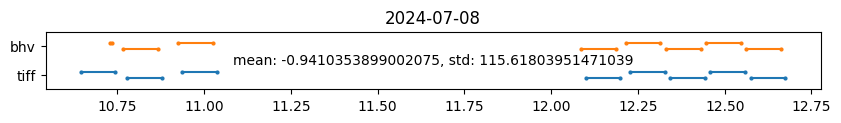

In [32]:
expt_date = date.fromisoformat("2024-07-08")

fig, ax = plt.subplots(figsize=(10,0.75))
plot_expt_file_intervals(expt_date, tiff_df, bhv_df, ax)

In [33]:
df_dicts = []
tiff_intervals = tiff_df_subset['interval']
bhv_intervals = bhv_df_subset['interval']
for tiff_interval in tiff_intervals:
    for bhv_interval in bhv_intervals:
        # Shift bhv file start to tiffs starting point
        shift = tiff_interval[0] - bhv_interval[0]
        shifted_bhv_intervals = shift_intervals(bhv_intervals, shift)
        coverage = calculate_coverage(tiff_intervals, shifted_bhv_intervals)
        coverage_with_dup = calculate_coverage(tiff_intervals, shifted_bhv_intervals, with_duplicates=True)
        df_dicts.append({"shift": shift,
                         "coverage": coverage,
                         "coverage_with_dup": coverage_with_dup})

coverage_df = pd.DataFrame(df_dicts)

In [34]:
tiff_df_subset = tiff_df[tiff_df['date'] == expt_date]
bhv_df_subset = bhv_df[bhv_df['date'] == expt_date]

In [35]:
# tiff_df_subset.iloc[0].tiff.metadata
tiff_df_subset

,path,tiff,datetime,date,interval,interval_sub_midnight
234,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 10:38:40.045530,2024-07-08,"(1720460320.04553, 1720460679.6720042)","[10.644457091689109, 10.744353334506352]"
235,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 10:46:42.337772,2024-07-08,"(1720460802.337772, 1720461162.0844822)","[10.778427158859042, 10.878356800609165]"
236,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 10:56:12.512269,2024-07-08,"(1720461372.512269, 1720461732.2589793)","[10.93680896361669, 11.036738605366814]"
237,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 12:05:58.045388,2024-07-08,"(1720465558.045388, 1720465917.7920983)","[12.09945705221759, 12.199386693967712]"
238,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 12:13:37.827949,2024-07-08,"(1720466017.827949, 1720466377.5746593)","[12.227174430290859, 12.327104072040981]"
239,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 12:20:35.453217,2024-07-08,"(1720466435.453217, 1720466795.1999273)","[12.343181449174882, 12.443111090925006]"
240,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 12:27:31.105077,2024-07-08,"(1720466851.105077, 1720467210.8517873)","[12.45864029917452, 12.558569940924645]"
241,Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluS...,<gulp2p.preproc.tiff.Tiff object at 0x00000234...,2024-07-08 12:34:29.201081,2024-07-08,"(1720467269.201081, 1720467628.9477913)","[12.574778078065979, 12.674707719816102]"


In [36]:
for path in tiff_df_subset['path']:
    print(path)

Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluSnfR_fly1_00001.tif
Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluSnfR_fly1_00002.tif
Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluSnfR_fly1_00003.tif
Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluSnfR_fly2_00001.tif
Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluSnfR_fly2_00002.tif
Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluSnfR_fly2_00003.tif
Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluSnfR_fly2_00004.tif
Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluSnfR_fly2_00005.tif


In [37]:
for path in bhv_df_subset['path']:
    print(path)

Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-07-08_10-43-45.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-07-08_10-45-58.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-07-08_10-55-28.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-07-08_12-05-13.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-07-08_12-12-53.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-07-08_12-19-51.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-07-08_12-26-46.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-07-08_12-33-45.json


best shift: 44.82794904708862
coverage: 0.8769414228561404


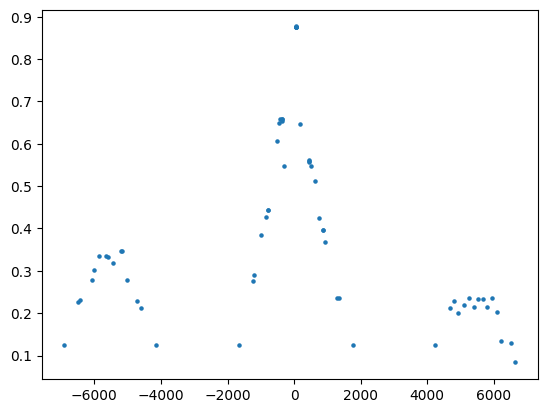

In [38]:
ax = plt.scatter(coverage_df['shift'], coverage_df['coverage'], s=5)
best_row = coverage_df.loc[coverage_df['coverage'].idxmax()]
print(f"best shift: {best_row['shift']}")
print(f"coverage: {best_row['coverage']}")
pass

In [39]:
coverage_df[coverage_df['coverage']>coverage_df['coverage'].quantile(0.90)].sort_values('coverage')

,shift,coverage,coverage_with_dup
63,44.201081,0.876317,0.876317
9,44.337772,0.876554,0.876554
45,44.453217,0.876715,0.876715
54,45.105077,0.876722,0.876722
18,44.512269,0.876776,0.876776
27,45.045388,0.876805,0.876805
36,44.827949,0.876941,0.876941


In [40]:
coverage_df.describe()

,shift,coverage,coverage_with_dup
count,64.000000,64.000000,64.000000
mean,0.941035,0.397688,0.397688
std,3894.023589,0.232434,0.232434
min,-6904.954470,0.083672,0.083672
25%,-1352.704612,0.228964,0.228964
50%,44.482743,0.333100,0.333100
75%,1442.629078,0.558522,0.558522
max,6644.201081,0.876941,0.876941


In [41]:
# Get shift with max coverage
best_shift = coverage_df.loc[coverage_df['coverage'].idxmax(), "shift"]

In [42]:
best_shift

44.82794904708862

### Plot overlaps

(12.5, 12.8)

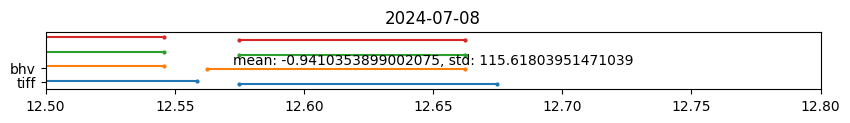

In [43]:
expt_date = date.fromisoformat("2024-07-08")

fig, ax = plt.subplots(figsize=(10,0.75))
plot_expt_file_intervals(expt_date, tiff_df, bhv_df, ax, with_overlaps=True)

ax.set_xlim([12.5, 12.8])